# NARR-to-PRISM Downscaling: Refinement Inference


This notebook runs the trained two-phase NARR-to-PRISM pipeline with any supported stochastic refinement head.

It will:
1. Resolve and validate the deterministic Phase-1 and recent Phase-2 `last.ckpt` files
2. Build or reuse validated FP32 Phase-1 tile conditioning for the refinement head
3. Generate the refined ensemble over the configured inference dates
4. Write daily refined NetCDF products without a separate Phase-1 output-file pass
5. Visualize the refined ensemble mean


---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
import sys
from pathlib import Path

# Set REPO_ROOT to the granite-wxc repository root
REPO_ROOT = Path(".").resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

NARR_PRISM_DIR = REPO_ROOT / "examples" / "NARR_PRISM"
if str(NARR_PRISM_DIR) not in sys.path:
    sys.path.insert(0, str(NARR_PRISM_DIR))

os.chdir(REPO_ROOT)
print(f"Repository root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")

Repository root: /data/granite-wxc
Working directory: /data/granite-wxc


In [2]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

In [3]:
!pip install -q h5netcdf matplotlib xarray scipy torch tqdm pyyaml

In [4]:
# Install granitewxc in editable mode from the repo source
!pip install -q -e {REPO_ROOT}

In [5]:
import logging
import warnings

logging.disable(logging.CRITICAL)
warnings.simplefilter(action="ignore", category=FutureWarning)

---

## Device Configuration

In [6]:
# ===================== HARDWARE CONFIGURATION (EDIT ME) =====================
# Select idle GPUs just before launching inference. One idle GPU is enough.
# None respects CUDA_VISIBLE_DEVICES; e.g. "1" restricts inference to GPU 1.
force_visible_devices = None
device_target = "cuda"       # "cuda" or "cpu"
# ============================================================================

import torch
import numpy as np
from narr_prism_utils import select_idle_gpus

if device_target == "cuda" and not torch.cuda.is_available():
    print("CUDA not available, falling back to CPU")
    device_target = "cpu"

# CUDA indices are local to the subprocess's selected GPUs. Keep the notebook
# environment unchanged so reruns also work after CUDA was initialized here.
device = torch.device("cuda:0" if device_target == "cuda" else "cpu")
print(f"Inference device: {device}")
print("Idle GPUs and worker count will be selected when inference starts.")


Inference device: cuda:0
Idle GPUs and worker count will be selected when inference starts.


---

## Configuration

Select any supported refinement configuration and choose inference controls.


In [7]:
from granitewxc.utils.config import get_config
from granitewxc.refinement import resolve_refinement_config
from narr_prism_utils import case_output_dir, get_case_name, load_yaml, resolve_path

# ===================== USER PARAMETERS (EDIT ME) =====================
CONFIG_PATH = NARR_PRISM_DIR / "NARR_PRISM_diffusion_unet.yaml"
PHASE1_CHECKPOINT_PATH = None       # None uses model.phase1.checkpoint from YAML
REFINEMENT_CHECKPOINT_PATH = None   # None uses checkpoint_dir/last.ckpt
PHASE1_CACHE_DIR = NARR_PRISM_DIR / "experiments" / "phase1_inference_cache"
OUTPUT_DIR = None                   # None uses the YAML refined-output default
BATCH_SIZE = 8                      # Spatial tiles per worker forward pass
NUM_GPUS = 4                         # Maximum idle GPUs; use 1 to cap at one worker
RESUME_EXISTING = True               # Validate and skip completed daily files
ENSEMBLE_SIZE = 10                   # Preserve the trained 10-member ensemble
SEED = None                         # None uses model.refinement.seed
LIMIT_DAYS = 0                      # 0 runs the complete configured date split
PREDICTION_SPLIT = "inference"      # "inference" or "validation"
# ====================================================================

config_path = str(CONFIG_PATH.resolve())
cfg = load_yaml(config_path)
config = get_config(config_path)
case_name = get_case_name(cfg)
refinement = resolve_refinement_config(config)
refinement_cfg = cfg.get("model", {}).get("refinement", {})
refinement_type = refinement.type

if not refinement.is_active:
    raise ValueError("The selected YAML does not enable model.refinement")
if PREDICTION_SPLIT not in {"inference", "validation"}:
    raise ValueError("PREDICTION_SPLIT must be 'inference' or 'validation'")

print(f"Config: {config_path}")
print(f"Case name: {case_name}")
print(f"Refinement type: {refinement_type}")
print(f"Target variables: {cfg['data']['target_variables']}")
print(
    f"{PREDICTION_SPLIT.title()} dates: "
    f"{cfg['dates'][PREDICTION_SPLIT]['start']} to "
    f"{cfg['dates'][PREDICTION_SPLIT]['end']}"
)


Config: /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_diffusion_unet.yaml
Case name: narr_prism_California
Refinement type: diffusion_unet
Target variables: ['ppt', 'tmax', 'tmin']
Inference dates: 2016-01-01 to 2025-12-31


---

## Locate and Validate Both Checkpoints

Phase 1 supplies deterministic conditioning from a reusable FP32 tile cache. Missing days are computed using the same checkpoint with autocast and TF32 disabled. Phase 2 is loaded from the selected refinement configuration directory's recent `last.ckpt`, unless an explicit override is supplied above.


In [8]:
from datetime import datetime, timezone
from pathlib import Path

phase1_setting = PHASE1_CHECKPOINT_PATH or (
    cfg.get("model", {}).get("phase1", {}).get("checkpoint")
)
if not phase1_setting:
    raise FileNotFoundError(
        "Set PHASE1_CHECKPOINT_PATH or model.phase1.checkpoint in the YAML"
    )
phase1_checkpoint_path = Path(resolve_path(phase1_setting)).resolve()

refinement_setting = REFINEMENT_CHECKPOINT_PATH or refinement_cfg.get("checkpoint")
if refinement_setting:
    refinement_checkpoint_path = Path(resolve_path(refinement_setting)).resolve()
else:
    checkpoint_dir = cfg.get("checkpoint_dir")
    if not checkpoint_dir:
        raise FileNotFoundError(
            "Set REFINEMENT_CHECKPOINT_PATH or checkpoint_dir in the YAML"
        )
    refinement_checkpoint_path = Path(resolve_path(checkpoint_dir)).resolve() / "last.ckpt"

for label, path in (
    ("Phase-1 deterministic", phase1_checkpoint_path),
    ("Phase-2 refinement", refinement_checkpoint_path),
):
    if not path.is_file():
        raise FileNotFoundError(f"{label} checkpoint not found: {path}")

# The Phase-2 file is small enough to inspect on CPU. Fail early if an old
# deterministic checkpoint was accidentally selected.
phase2_metadata = torch.load(
    refinement_checkpoint_path,
    map_location="cpu",
    mmap=True,
    weights_only=False,
)
checkpoint_kind = phase2_metadata.get("checkpoint_kind")
checkpoint_type = phase2_metadata.get("refinement_type")
checkpoint_epoch = phase2_metadata.get("epoch")
if checkpoint_kind != "refinement":
    raise ValueError(
        f"Expected a refinement checkpoint, got checkpoint_kind={checkpoint_kind!r}"
    )
if checkpoint_type != refinement_type:
    raise ValueError(
        f"Checkpoint refinement_type={checkpoint_type!r} does not match "
        f"YAML type={refinement_type!r}"
    )
del phase2_metadata

modified = datetime.fromtimestamp(
    refinement_checkpoint_path.stat().st_mtime, tz=timezone.utc
).isoformat()
print(f"Phase-1 checkpoint: {phase1_checkpoint_path}")
print(f"Phase-2 checkpoint: {refinement_checkpoint_path}")
print(f"Phase-2 epoch: {checkpoint_epoch}")
print(f"Phase-2 modified (UTC): {modified}")


Phase-1 checkpoint: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt
Phase-2 checkpoint: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/refinement_checkpoints/diffusion_unet/last.ckpt
Phase-2 epoch: 100
Phase-2 modified (UTC): 2026-09-01T18:44:25.620378+00:00


---

## Model Loading

The refinement command loads the frozen Phase-1 network and the configured Phase-2 refinement head inside a subprocess, so the notebook kernel does not retain duplicate GPU model copies.


In [9]:
print("Checkpoint metadata validated. Models will load when refined inference starts.")


Checkpoint metadata validated. Models will load when refined inference starts.


---

## Run Refined Inference

The command uses up to `NUM_GPUS` idle GPUs, falling back to a single worker when only one is free. Set `NUM_GPUS = 1` to always use at most one GPU. The child process receives only the selected GPUs; existing `CUDA_VISIBLE_DEVICES` restrictions are respected unless `force_visible_devices` is set. If all eligible GPUs are busy, the cell reports that no idle GPU is available so you can retry later or select CPU.

GPU occupancy is checked immediately before launch (no compute processes, at most 1 GiB used and 5% utilization); this check does not reserve the GPUs.

The command shards dates across the selected workers, resumes validated daily products, builds or reuses FP32 Phase-1 conditioning, and writes one refined daily NetCDF file per date. One terminal-style text bar tracks aggregate tile batches across all workers, including resumed work. It updates the same notebook output in place and shows percentage, elapsed time, and ETA once counts are available. Child process bars stay disabled, so no extra bars are printed. Diagnostics are written to a timestamped file in `NARR_PRISM/logs`; failures also show the end of that log in the cell. It does not run the separate deterministic-output-file workflow.

The shared `PHASE1_CACHE_DIR` stores physical and normalized tile outputs before overlap blending, preserving the grid, mask, halo, scaler offsets, and refinement conditioning. Checkpoint, normalization, grid, mask, geometry, and predictor-content checks prevent stale reuse. Each run checks a cached batch against live FP32 Phase 1 (absolute tolerance `1e-5`). Existing BF16 daily output files are not imported into this cache.

The first run builds missing cache days as it goes; subsequent refinement heads reuse them. Refined products without the matching cache identity are recomputed when resuming. The training residual cache and training statistics remain separate.

The foreground run depends on this notebook kernel staying alive. For a long run that must continue after closing VS Code, launch `./run_inference_tmux.sh` from the `NARR_PRISM` directory and inspect its log with `./run_inference_tmux.sh logs`. Start only one run at a time. With `RESUME_EXISTING = True`, reruns validate and skip completed days and reuse cached Phase-1 tiles.


In [10]:
import shlex
import subprocess
from datetime import datetime, timezone
from examples.NARR_PRISM.narr_prism_progress import inference_progress

inference_cfg = cfg.get("inference", {})
if OUTPUT_DIR is None:
    base_output = inference_cfg.get(
        "refinement_output_dir",
        inference_cfg.get(
            "output_dir",
            "./examples/NARR_PRISM/experiments/inference_output",
        ),
    )
    output_root = Path(resolve_path(base_output)).resolve() / f"refinement_{refinement_type}"
else:
    output_root = Path(OUTPUT_DIR).expanduser().resolve()

# Refresh occupancy at launch and isolate only the selected GPUs in the child.
inference_env = os.environ.copy()
# The notebook owns the single bar; child processes only report counts.
inference_env["TQDM_DISABLE"] = "1"
if device.type == "cuda":
    selected_gpu_ids = select_idle_gpus(NUM_GPUS, force_visible_devices)
    inference_env["CUDA_VISIBLE_DEVICES"] = ",".join(selected_gpu_ids)
    worker_count = len(selected_gpu_ids)
    print(f"Using {worker_count} idle GPU(s), requested up to {NUM_GPUS}.")
    print(f"Selected GPU UUIDs: {inference_env['CUDA_VISIBLE_DEVICES']}")
else:
    worker_count = 1

command = [
    sys.executable,
    "-u",  # Flush diagnostics promptly to the run log.
    str(NARR_PRISM_DIR / "narr_prism_refinement.py"),
    "infer",
    "--config",
    config_path,
    "--phase1-checkpoint",
    str(phase1_checkpoint_path),
    "--phase1-cache-dir",
    str(PHASE1_CACHE_DIR.resolve()),
    "--refinement-checkpoint",
    str(refinement_checkpoint_path),
    "--device",
    str(device),
    "--batch-size",
    str(BATCH_SIZE),
    "--num-gpus",
    str(worker_count),
    "--output",
    str(output_root),
    "--split",
    PREDICTION_SPLIT,
    "--no-progress",
]
if RESUME_EXISTING:
    command.append("--resume-existing")
if ENSEMBLE_SIZE is not None:
    command.extend(["--ensemble-size", str(ENSEMBLE_SIZE)])
if SEED is not None:
    command.extend(["--seed", str(SEED)])
if LIMIT_DAYS:
    command.extend(["--limit-days", str(LIMIT_DAYS)])

print(f"Shared FP32 Phase-1 cache: {PHASE1_CACHE_DIR.resolve()}")
print("Missing cache days will be computed once; validated days are reused.")
# Retain diagnostics even when the notebook output is cleared or disconnected.
log_dir = NARR_PRISM_DIR / "logs"
log_dir.mkdir(parents=True, exist_ok=True)
run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
log_path = log_dir / f"inference_{run_stamp}.log"
progress_path = log_path.with_suffix(".progress.json")
command.extend(["--progress-file", str(progress_path)])
print("Running refined inference:")
print(shlex.join(command))
print(f"Run log: {log_path}")
with log_path.open("w", encoding="utf-8") as log:
    print(f"[notebook] start (UTC): {run_stamp}", file=log, flush=True)
    print(shlex.join(command), file=log, flush=True)
    try:
        with inference_progress(progress_path):
            subprocess.run(command, cwd=str(REPO_ROOT), env=inference_env, check=True,
                           stdout=log, stderr=subprocess.STDOUT)
    except subprocess.CalledProcessError as exc:
        print(f"[notebook] inference failed: exit {exc.returncode}", file=log, flush=True)
        print("\n".join(log_path.read_text(errors="replace").splitlines()[-30:]))
        print(f"Full inference log: {log_path}")
        raise
    except KeyboardInterrupt:
        print("[notebook] inference interrupted", file=log, flush=True)
        print(f"Inference interrupted. Run log: {log_path}")
        raise
    else:
        print(f"[notebook] completed (UTC): {datetime.now(timezone.utc).isoformat()}",
              file=log, flush=True)

split_output_root = (
    output_root
    if PREDICTION_SPLIT == "inference"
    else output_root / "validation"
)
output_path = case_output_dir(split_output_root, case_name)
print(f"\nRefined inference output saved to: {output_path}")


Using 1 idle GPU(s), requested up to 4.
Selected GPU UUIDs: GPU-e54a4f1d-05d9-b748-04f0-8d7925441a59
Shared FP32 Phase-1 cache: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/phase1_inference_cache
Missing cache days will be computed once; validated days are reused.
Running refined inference:
/home/azureuser/miniforge3/envs/Prithvi/bin/python -u /data/granite-wxc/examples/NARR_PRISM/narr_prism_refinement.py infer --config /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_diffusion_unet.yaml --phase1-checkpoint /data2/granite-wxc-artifacts/NARR_PRISM/experiments/checkpoints/narr_prism_California/last.ckpt --phase1-cache-dir /data2/granite-wxc-artifacts/NARR_PRISM/experiments/phase1_inference_cache --refinement-checkpoint /data2/granite-wxc-artifacts/NARR_PRISM/experiments/refinement_checkpoints/diffusion_unet/last.ckpt --device cuda:0 --batch-size 8 --num-gpus 1 --output /data2/granite-wxc-artifacts/NARR_PRISM/experiments/inference_output/refinement_diffusion_unet --split inference 

Refined inference: 100%|####################################| 10959/10959 [119:18:48<00:00, 39.19s/tile-batch]


Refined inference output saved to: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/inference_output/refinement_diffusion_unet/narr_prism_California


---

## Visualize Refined Results

Load the refined daily NetCDF products and plot each target variable's ensemble mean. Phase-1 baseline fields remain available as `<variable>_phase1` inside the same files for optional comparison; no separate Phase-1 files are required.


In [11]:
from pathlib import Path
import xarray as xr

output_path = Path(output_path)
file_pattern = f"{case_name}_{refinement_type}_refined_*.nc"
nc_files = sorted(output_path.glob(file_pattern))
if not nc_files:
    raise FileNotFoundError(
        f"No refined daily NetCDF files matching {file_pattern!r} in {output_path}"
    )

try:
    # Preferred path when dask is available: keep the daily files lazily combined.
    ds = xr.open_mfdataset([str(p) for p in nc_files], combine="by_coords")
except (ImportError, ValueError) as exc:
    if len(nc_files) <= 512:
        # Dependency-light fallback for small inference runs.
        daily = [xr.open_dataset(str(p)) for p in nc_files]
        ds = xr.concat(daily, dim="time")
    else:
        print(
            "Install dask to lazily open all daily files with xr.open_mfdataset; "
            "showing the first daily file for inspection."
        )
        print(f"open_mfdataset error: {exc}")
        ds = xr.open_dataset(str(nc_files[0]))

print(f"Daily refined files: {len(nc_files)}")
print(f"Refinement type in output: {ds.attrs.get('refinement_type', 'n/a')}")
print(f"Phase-2 checkpoint in output: {ds.attrs.get('phase2_checkpoint', 'n/a')}")
print(ds)
print(f"\nTime steps available: {len(nc_files)}")
print(f"Time steps opened in ds: {ds.sizes.get('time', 'n/a')}")
print(f"Spatial grid: {ds.sizes.get('lat', 'n/a')} x {ds.sizes.get('lon', 'n/a')}")


Daily refined files: 3653
Refinement type in output: diffusion_unet
Phase-2 checkpoint in output: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/refinement_checkpoints/diffusion_unet/last.ckpt
<xarray.Dataset> Size: 601GB
Dimensions:               (time: 3653, lat: 1024, lon: 1024)
Coordinates:
  * time                  (time) datetime64[ns] 29kB 2016-01-01 ... 2025-12-31
  * lat                   (lat) float64 8kB 32.55 32.56 32.57 ... 41.07 41.08
  * lon                   (lon) float64 8kB -124.5 -124.4 ... -115.9 -115.9
Data variables: (12/40)
    prism_valid_mask      (time, lat, lon) uint8 4GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    ppt                   (time, lat, lon) float32 15GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    ppt_phase1            (time, lat, lon) float32 15GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    ppt_member_000        (time, lat, lon) float32 15GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
 

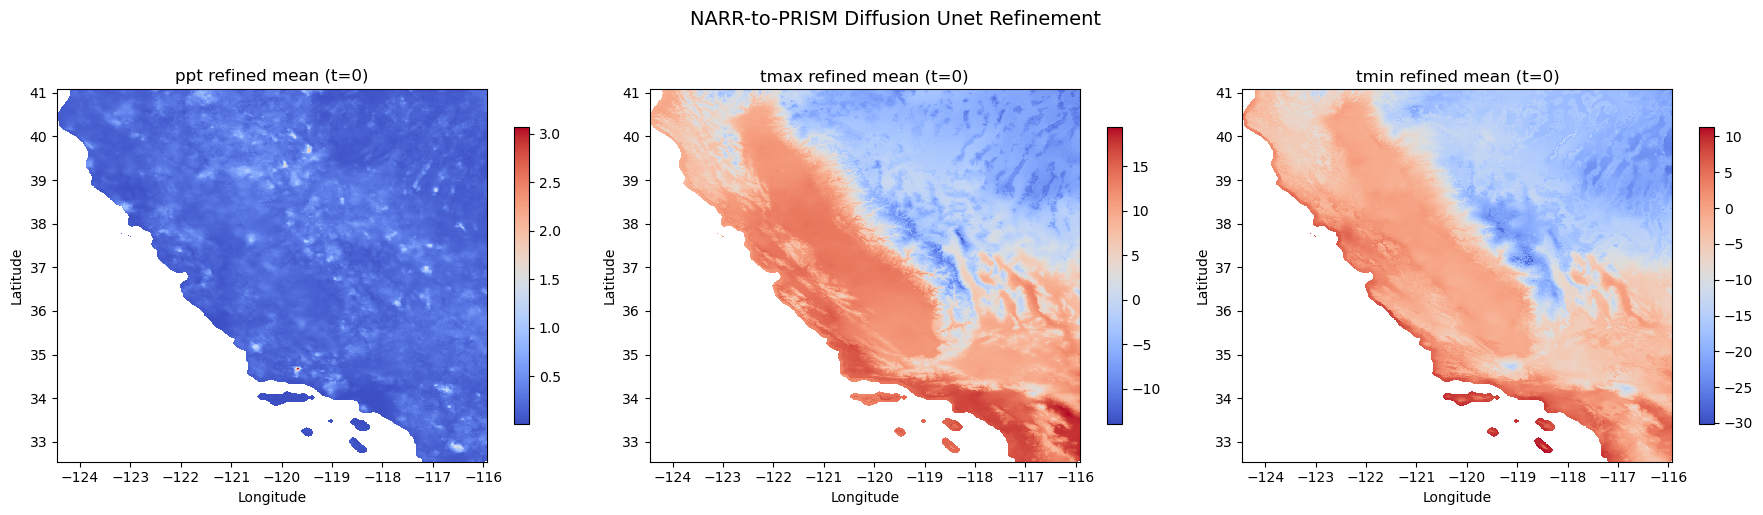

In [12]:
import matplotlib.pyplot as plt

target_variables = cfg["data"]["target_variables"]
n_vars = len(target_variables)

fig, axes = plt.subplots(1, n_vars, figsize=(6 * n_vars, 5))
if n_vars == 1:
    axes = [axes]

# The base variable is the refined ensemble mean; member and Phase-1 fields
# remain available in the same dataset for uncertainty/baseline diagnostics.
for ax, var in zip(axes, target_variables):
    data = ds[var].isel(time=0)
    im = ax.pcolormesh(ds.lon, ds.lat, data.values, shading="auto", cmap="coolwarm")
    ax.set_title(f"{var} refined mean (t=0)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, shrink=0.8)

refinement_label = refinement_type.replace("_", " ").title()
plt.suptitle(f"NARR-to-PRISM {refinement_label} Refinement", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [13]:
ds.close()
print("Done.")

Done.


---

## Summary

The notebook now:
1. Computes missing Phase-1 conditioning once in strict FP32 and reuses validated cached tiles
2. Loads the recent `last.ckpt` from the selected refinement configuration directory
3. Validates that the selected Phase-2 artifact is a matching refinement checkpoint
4. Resumes validated existing days and shards remaining dates across available idle GPUs, including a single GPU
5. Uses tile batch size 8 while preserving all 10 ensemble members
6. Writes daily refined products without a separate set of Phase-1 output files

Default output location:
```
examples/NARR_PRISM/experiments/inference_output/refinement_<refinement_type>/<case_name>/
```
